In [15]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
import re

In [16]:
# Load the data
data = pd.read_excel('SinhalaSpellingCheckerDataSet2.xlsx')
data.head()

,word,label
0,අංක,1
1,අංකට්ටා,1
2,අංකඩ,1
3,අංකණයෙන්,1
4,අංකන,1


In [17]:
# Data preprocessing
X = data['word'].apply(lambda x: x.lower())  # Lowercasing
X = X.apply(lambda x: re.sub(r'[^\w\s]', '', x))  # Remove special characters
y = data['label']

In [18]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Feature extraction using Bag-of-Words
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

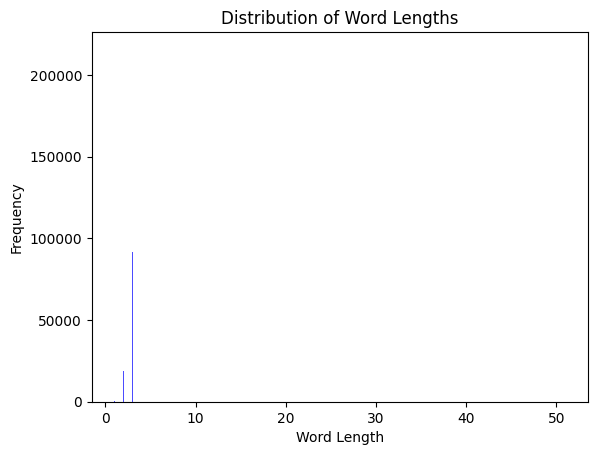

In [20]:
# Visualization: Word count distribution
word_lengths = X.apply(len)
plt.hist(word_lengths, bins='auto', alpha=0.7, color='blue')
plt.title('Distribution of Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

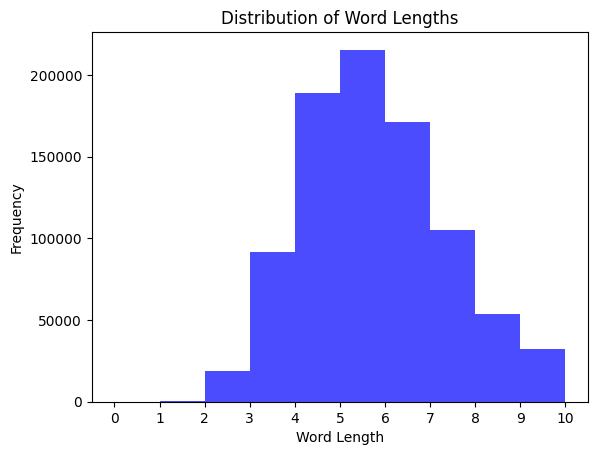

In [21]:
# Visualization: Word count distribution
word_lengths = X.apply(len)
plt.hist(word_lengths, bins=range(11), alpha=0.7, color='blue')
plt.title('Distribution of Word Lengths')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.xticks(range(11))
plt.show()

In [22]:
# Naive Bayes
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_vectorized, y_train)
nb_predictions = nb_classifier.predict(X_test_vectorized)
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.6486304623179228
              precision    recall  f1-score   support

           0       0.88      0.33      0.48     87248
           1       0.60      0.96      0.73     89600

    accuracy                           0.65    176848
   macro avg       0.74      0.64      0.61    176848
weighted avg       0.74      0.65      0.61    176848

